In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [40]:
master_df = pd.read_csv("../data/processed/master_dataset_v1.csv")
df = master_df.copy()

In [41]:
df.head()

,state,year,gdp,income_pc,real_income_pc,rpp
0,Alabama,2008,174665.6,33441.0,42219.0,88.901
1,Alabama,2009,170876.5,32717.0,41966.0,87.786
2,Alabama,2010,177510.7,33848.0,41709.0,89.783
3,Alabama,2011,182896.7,34884.0,41819.0,90.011
4,Alabama,2012,188280.7,35559.0,41592.0,90.559


# 1. Income vs Real Income

### Does higher income actually mean better living standards?

- We examined whether higher income leads to higher real income, which reflects the actual purchasing power per capita

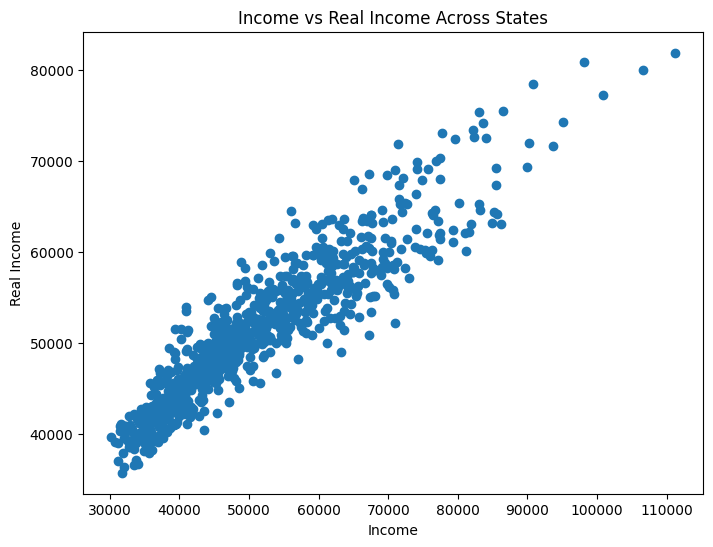

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(df["income_pc"], df["real_income_pc"])

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title("Income vs Real Income Across States")

plt.show()

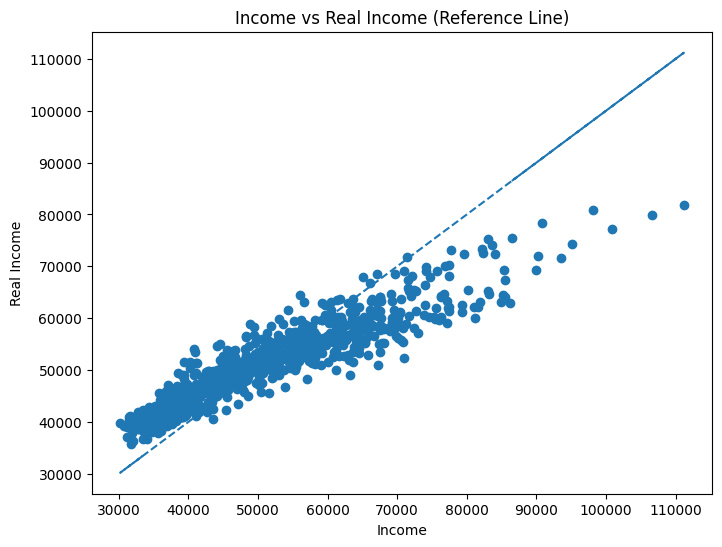

Correlation = 0.92


In [43]:
x = df["income_pc"]
y = df["real_income_pc"]

plt.figure(figsize=(8,6))
plt.scatter(x, y)

# reference line

plt.plot(x, x, linestyle='--')

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title("Income vs Real Income (Reference Line)")

plt.show()

# correlation
corr = df["income_pc"].corr(df["real_income_pc"])
print(F"Correlation = {corr:.2f}")

In [44]:
x = df["income_pc"]
y = df["real_income_pc"]

slope, intercept = np.polyfit(x, y, 1)

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.2f}")

Slope: 0.5497
Intercept: 23160.45


In [45]:
X = df["income_pc"]
y = df["real_income_pc"]

# Add constant for intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         real_income_pc   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     5118.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:33:37   Log-Likelihood:                -8158.1
No. Observations:                 867   AIC:                         1.632e+04
Df Residuals:                     865   BIC:                         1.633e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.316e+04    406.853     56.926      0.0

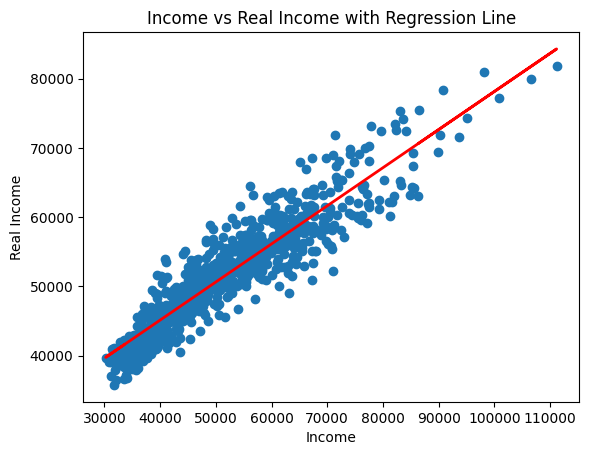

In [46]:
# add regession to graph

plt.scatter(df["income_pc"], df["real_income_pc"])
plt.plot(df["income_pc"], model.predict(X), color='red', linewidth=2)

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title("Income vs Real Income with Regression Line")

plt.show()

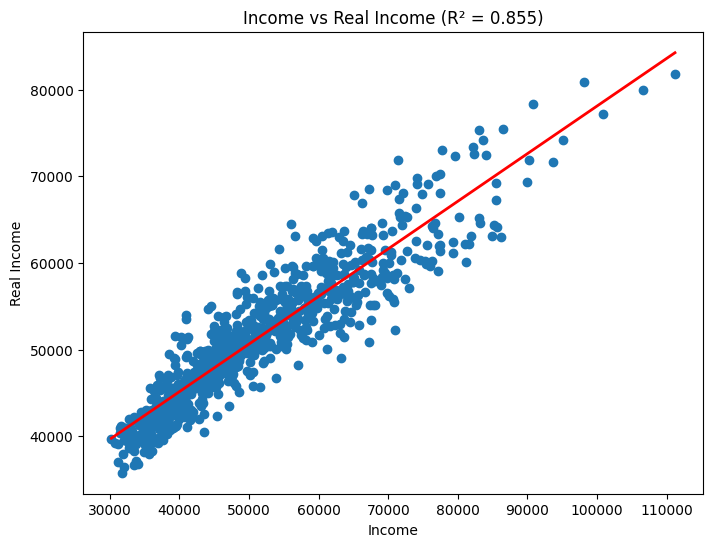

In [59]:
df_sorted = df.sort_values("income_pc")

X_sorted = sm.add_constant(df_sorted["income_pc"])
y_pred_sorted = model.predict(X_sorted)

plt.figure(figsize=(8,6))

# scatter (original data)
plt.scatter(df["income_pc"], df["real_income_pc"])

# regression line (sorted)
plt.plot(df_sorted["income_pc"], y_pred_sorted, color='red', linewidth=2)

plt.xlabel("Income")
plt.ylabel("Real Income")
plt.title(f"Income vs Real Income (R² = {model.rsquared:.3f})")

plt.show()

In [53]:
#residuals

df["predicted"] = model.predict(X)
df["residual"] = df["real_income_pc"] - df["predicted"]


In [55]:
# worst
df.sort_values("residual").head(20)

,state,year,gdp,income_pc,real_income_pc,rpp,predicted,residual
203,Hawaii,2024,117627.4,71019.0,52272.0,109.951,62197.338934,-9925.338934
202,Hawaii,2023,111740.2,67269.0,50923.0,109.703,60136.082911,-9213.082911
201,Hawaii,2022,103954.5,63184.0,49022.0,111.148,57890.688018,-8868.688018
83,California,2023,3827007.3,81196.0,60100.0,112.195,67791.312944,-7691.312944
84,California,2024,4048108.1,86232.0,63028.0,110.720,70559.442365,-7531.442365
644,Oregon,2023,314895.0,67467.0,53455.0,104.812,60244.917229,-6789.917229
200,Hawaii,2021,93684.2,61264.0,50046.0,112.564,56835.324934,-6789.324934
526,New Jersey,2024,846000.4,84893.0,63142.0,108.805,69823.436548,-6681.436548
643,Oregon,2022,297084.3,63669.0,51501.0,106.612,58157.277130,-6656.277130
645,Oregon,2024,330250.1,70823.0,55451.0,103.361,62089.603952,-6638.603952


In [56]:
#best
df.sort_values("residual").tail(20)

,state,year,gdp,income_pc,real_income_pc,rpp,predicted,residual
592,North Dakota,2022,75052.1,71011.0,69036.0,88.703,62192.941587,6843.058413
704,South Dakota,2015,48678.9,48308.0,56644.0,87.799,49713.822794,6930.177206
587,North Dakota,2017,56530.2,51830.0,58594.0,88.664,51649.754450,6944.245550
711,South Dakota,2022,69425.6,69752.0,68469.0,87.851,61500.909232,6968.090768
864,Wyoming,2022,49570.4,77768.0,73081.0,91.767,65907.050105,7173.949895
860,Wyoming,2018,39614.5,59197.0,62928.0,92.372,55699.160615,7228.839385
591,North Dakota,2021,64830.0,66158.0,66878.0,90.962,59525.401460,7352.598540
580,North Dakota,2010,35651.8,44081.0,54744.0,89.083,47390.375006,7353.624994
700,South Dakota,2011,42082.7,44532.0,55061.0,87.272,47638.275397,7422.724603
585,North Dakota,2015,56952.2,52972.0,59886.0,91.063,52277.475618,7608.524382


In [62]:
#state avg residual

state_avg = df.groupby("state")["residual"].mean().sort_values()

In [60]:
state_avg.head(10)   # worst states


state
Hawaii       -6009.316933
California   -3690.960814
Arizona      -3622.675614
Oregon       -3372.718587
Utah         -2912.443527
New Mexico   -2547.027089
Florida      -2405.625774
Nevada       -1972.298793
Idaho        -1819.490626
New York     -1812.031549
Name: residual, dtype: float64

In [61]:
state_avg.tail(10)   # best states

state
Massachusetts           1702.759704
Oklahoma                2091.862282
District of Columbia    2832.788836
Kansas                  2842.868514
Iowa                    3008.551949
Connecticut             3583.110446
Nebraska                4304.066310
Wyoming                 5997.098694
South Dakota            6062.249377
North Dakota            6916.492631
Name: residual, dtype: float64

In [58]:
df["gdp"].corr(df["residual"])

np.float64(-0.2694022906647976)

As GDP increases, residuals tend to decrease (moderate corr)

- States with larger economies tend to underperform in real income relative to expectations

### Insights

- Income and real income are strongly correlated (R² = 0.855)
- The relationship is not perfect, indicating variation across states
- Some states outperform or underperform expected real income levels
- This suggests that income alone does not determine economic well-being
- Cost of living is likely a key factor influencing these differences